# Stack tSZ based on SNR

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np, os, glob
from pylab import *

In [3]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'
rcParams['font.family'] = 'serif'

In [275]:
mask_threshold_sigma_units_arr = [(5.,10.), (10., 20.), (20., 100.)] #[5., 10., 50., 100.]
which_tsz_arr = ['agora', 'ddpm']
cutout_size_am_reqd = 30.
dx_am = 1.40625
cutout_size_pixels = int( cutout_size_am_reqd / dx_am ) + 1
if cutout_size_pixels%2 != 0:
    cutout_size_pixels = cutout_size_pixels + 1
    
#cutout_size_pixels = int(cutout_size_pixels)
cutout_size_am = cutout_size_pixels * dx_am
print( cutout_size_am )

30.9375


In [277]:
for which_tsz in which_tsz_arr:
    print('\ntsz = %s' %(which_tsz))
    if which_tsz == 'agora':
        fname = 'data/low_pass/2mjy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz3_no_pickle.npy'
        tsz_dic = np.load(fname, allow_pickle=True)
        total_sims = len(tsz_dic) ##1000 #200 #50 ##len( tsz_dic )
        ##print(len(tsz_dic))
    elif which_tsz == 'ddpm':
        fname = 'data/low_pass/2mjy/new_samples_16_cib_tsz3_2mJy_zero_norm_6x6_w_au_lp_varscaled_no_pickle.npy'
        tsz_array = np.load(fname, allow_pickle=True)
        total_sims = len(tsz_array) ##1000 #200 #50 ##len( tsz_dic )
        ##print(len(tsz_array))

    cutout_dic = {}
    for threshold in mask_threshold_sigma_units_arr:
        threshold1, threshold2 = threshold
        print('\nmask_threshold_sigma_units = (%s,%s)' %(threshold1, threshold2))
        cutout_arr = []
        for sim_no in range( total_sims ):
            ##print(sim_no)
            if which_tsz == 'agora':
                tszmap = tsz_dic[sim_no][:, :, 0]
            elif which_tsz == 'ddpm':
                tszmap = tsz_array[sim_no, :, :, 1]
                #print(tszmap.shape)
                ##imshow(tszmap); colorbar(); show(); sys.exit()
            ###tszmap = tszmap - np.mean(tszmap)

            #--------------------
            #--------------------
            #get locations closer to the mean
            mean_val = np.mean(tszmap)
            cond1 = abs(tszmap - mean_val) > threshold1 * np.std(tszmap)
            cond2 = abs(tszmap - mean_val) <= threshold2 * np.std(tszmap)
            yinds, xinds = np.where( (cond1) & (cond2) )
            #print('\tsim = %s: %s' %(sim_no, len(yinds)), end = '\t\t')

            for x,y in zip(xinds, yinds):
                #print(x, y)
                x1, x2 = int( x-cutout_size_pixels/2 ),  int( x+cutout_size_pixels/2 )
                y1, y2 =  int( y-cutout_size_pixels/2 ),  int( y+cutout_size_pixels/2 )
                ny, nx = tszmap.shape
                if (x2-x1 != y2-y1) or (x2-x1 != cutout_size_pixels) or (y2-y1 != cutout_size_pixels): continue #ignore clusters at the edges
                ##print(x, y, x1, x2, y1, y2)
                curr_cutout = np.zeros( (cutout_size_pixels, cutout_size_pixels) )
                if y1<0 or x1<0 or x2>nx or y2>ny: continue
                curr_cutout = tszmap[y1:y2, x1:x2]
                #print(x2-x1, y2-y1, 'hi')
                #print(curr_cutout.shape); sys.exit()
                cutout_arr.append( curr_cutout )

                '''
                imshow(tszmap, origin = 'lower'); colorbar(); plot(x, y, 'kx'); show(); 
                imshow(curr_cutout); colorbar()
                axhline(cutout_size_pixels/2, color = 'black'); axvline(cutout_size_pixels/2, color = 'black'); show(); sys.exit()
                '''

        cutout_arr = np.asarray( cutout_arr )
        print(cutout_arr.shape); #sys.exit()
        cutout_dic[threshold] = np.asarray( cutout_arr )
    opfname = 'tsz_extracts/%s_tsz_stacks.npy' %(which_tsz)
    np.save(opfname, cutout_dic)
    print('\n')


tsz = agora

mask_threshold_sigma_units = (5.0,10.0)
(285393, 22, 22)

mask_threshold_sigma_units = (10.0,20.0)
(65268, 22, 22)

mask_threshold_sigma_units = (20.0,100.0)
(4238, 22, 22)



tsz = ddpm

mask_threshold_sigma_units = (5.0,10.0)
(278633, 22, 22)

mask_threshold_sigma_units = (10.0,20.0)
(66906, 22, 22)

mask_threshold_sigma_units = (20.0,100.0)
(4799, 22, 22)




# Gaussian realisaitons of noise

In [ ]:
noise_val = 

# plot

-15.46875 15.46875
-27.0 -8


/var/folders/08/mkcy0rls72j2q09krs7qx2jw0000gn/T/ipykernel_41111/4028414955.py:43: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  subplot( tr, tc, sbpl); imshow( to_plot, origin = 'lower', aspect = 'auto', extent = [x1_am, x2_am, y1_am, y2_am], vmin = curr_vmin, vmax = curr_vmax, cmap = cmap)#; colorbar()


-15.46875 15.46875
-27.0 -8
-15.46875 15.46875
-27.0 -8


<Figure size 900x600 with 0 Axes>

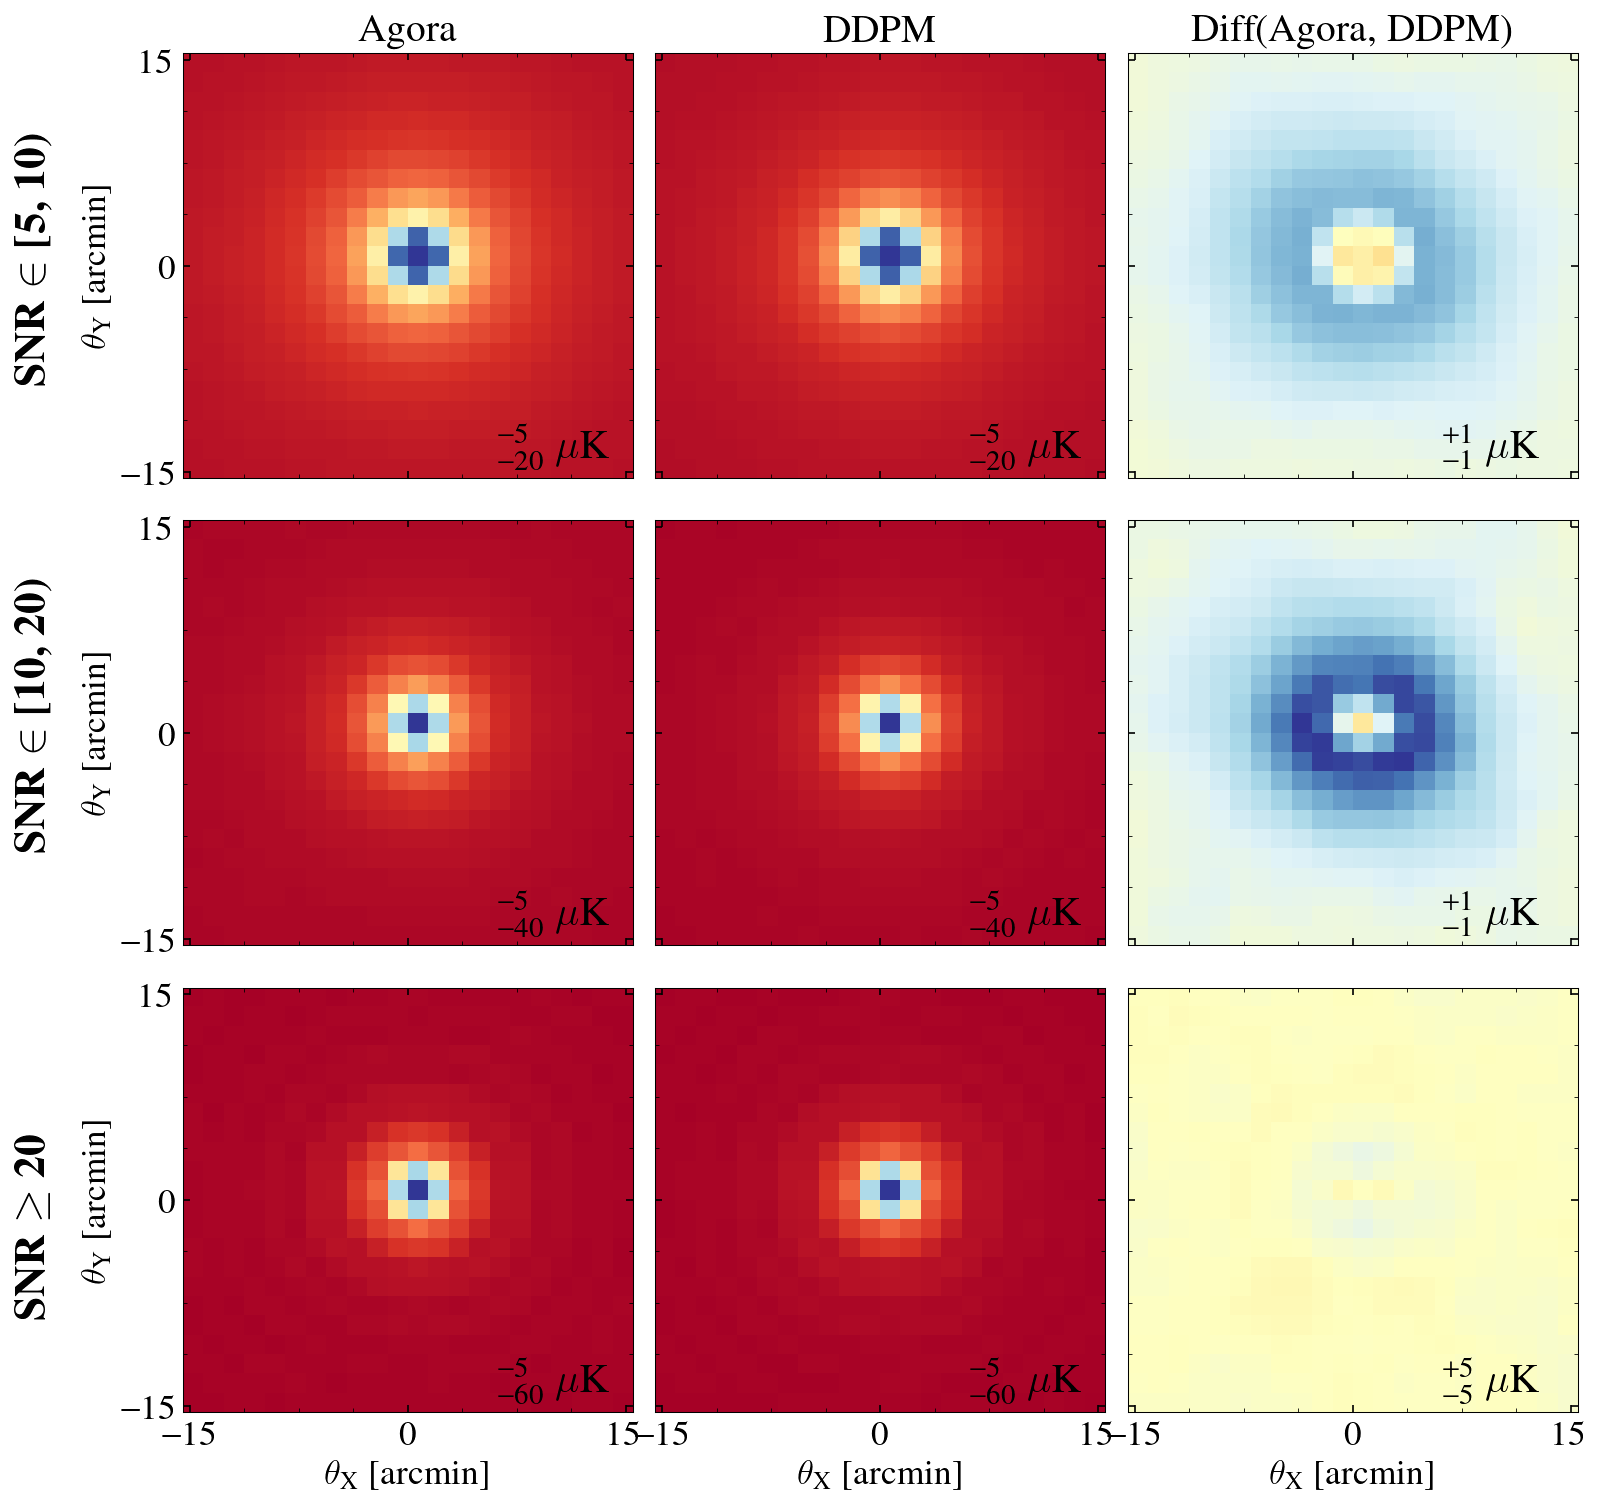

In [278]:
clf()
cmap = cm.RdYlBu_r #cm.jet
fsval = 17
figure(figsize = (12., 12))
tr, tc = len(mask_threshold_sigma_units_arr), 3
subplots_adjust( wspace = 0.05, hspace = 0.1)
sbpl = 1
for thresholdcntr, threshold in enumerate( mask_threshold_sigma_units_arr ):
    if threshold == (5.,10.):
        vmin, vmax = -20., -5.
        vmin_res, vmax_res = -1, 1
    elif threshold == (10., 20.):
        vmin, vmax = -40., -5.
        vmin_res, vmax_res = -1., 1
    elif threshold == (20., 100.):
        vmin, vmax = -60., -5.
        vmin_res, vmax_res = -5., 5
        
    pl_arr = []
    for which_tsz in which_tsz_arr:
        curr_fname = 'tsz_extracts/%s_tsz_stacks.npy' %(which_tsz)
        cutout_dic = np.load(curr_fname, allow_pickle = True).item()    
        
        cutout_arr = cutout_dic[threshold]
        #print(cutout_arr); sys.exit()
        cutout_stack = np.mean( cutout_arr, axis = 0 )
    
        pl_arr.append( cutout_stack )
    
    #plot stacks now
    pl_arr.append( pl_arr[0] - pl_arr[1] )
    x1_am, x2_am = y1_am, y2_am = -cutout_size_am/2, cutout_size_am/2
    xarr 
    print(x1_am, x2_am)
    title_arr = ['Agora', 'DDPM', 'Diff(Agora, DDPM)']
    for to_plot_cntr, to_plot in enumerate( pl_arr ):
        ax = subplot(tr, tc, sbpl)
        if to_plot_cntr in [0, 1]:
            curr_vmin, curr_vmax = vmin, vmax
        else:
            curr_vmin, curr_vmax = vmin_res, vmax_res
        ny, nx = cutout_stack.shape
        subplot( tr, tc, sbpl); imshow( to_plot, origin = 'lower', aspect = 'auto', extent = [x1_am, x2_am, y1_am, y2_am], vmin = curr_vmin, vmax = curr_vmax, cmap = cmap)#; colorbar()
        xloc, yloc = x2_am * 0.4, x1_am * 0.9
        if curr_vmax>0:
            text(xloc, yloc, r'{\bf $^{+%g}_{%g}$} $\mu {\rm K}$' %(curr_vmax, curr_vmin), fontsize = fsval+3)
        else:
            text(xloc, yloc, r'{\bf $^{%g}_{%g}$} $\mu {\rm K}$' %(curr_vmax, curr_vmin), fontsize = fsval+3)
        if thresholdcntr == 0:
            title(r'%s' %(title_arr[to_plot_cntr]), fontsize = fsval+2)
        xycen = (x2_am + x1_am)/2
        #axhline(xycen, lw = 0.2, alpha = 0.5); axvline(xycen, lw = 0.2, alpha = 0.5)

        tit_val = r'SNR $\in$ [%g, %g)' %(threshold[0], threshold[1])
        if thresholdcntr==len(mask_threshold_sigma_units_arr)-1:
            tit_val = r'SNR $\ge$ %g' %(threshold[0])
        
        if sbpl in [7, 8, 9]:
            xlabel(r'$\theta_{\rm X}$ [arcmin]', fontsize = fsval)
        else:
            setp(ax.get_xticklabels(which = 'both'), visible=False)
        if sbpl in [1, 4, 7]:
            #ylabval = r'{\bf %s}' %(tit_val) + '\n\n' + r'$\theta_{\rm Y}$ [arcmin]'
            ylabval = r'$\theta_{\rm Y}$ [arcmin]'            
            ylabel(ylabval, fontsize = fsval)
            
            #xloc, yloc = ax.yaxis.label.get_position()
            xloc, yloc = -27., -8
            text(xloc, yloc, r'{\bf %s}' %(tit_val), fontsize = fsval+4, rotation = 90.)
            print(xloc, yloc)
        else:
            setp(ax.get_yticklabels(which = 'both'), visible=False)
            
        #title(tit_val, fontsize = fsval+2, y = 0.87)
        #axis('off')
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.yaxis.set_major_locator(plt.MaxNLocator(3))
        for label in ax.get_xticklabels(): label.set_fontsize(fsval)
        for label in ax.get_yticklabels(): label.set_fontsize(fsval)
        sbpl+=1
show()
    

# Radial profile now

[ 0.703125  2.109375  3.515625  4.921875  6.328125  7.734375  9.140625
 10.546875 11.953125 13.359375 14.765625 16.171875 17.578125 18.984375
 20.390625]
[ 0.703125  2.109375  3.515625  4.921875  6.328125  7.734375  9.140625
 10.546875 11.953125 13.359375 14.765625 16.171875 17.578125 18.984375
 20.390625]
[ 0.703125  2.109375  3.515625  4.921875  6.328125  7.734375  9.140625
 10.546875 11.953125 13.359375 14.765625 16.171875 17.578125 18.984375
 20.390625]


<Figure size 900x600 with 0 Axes>

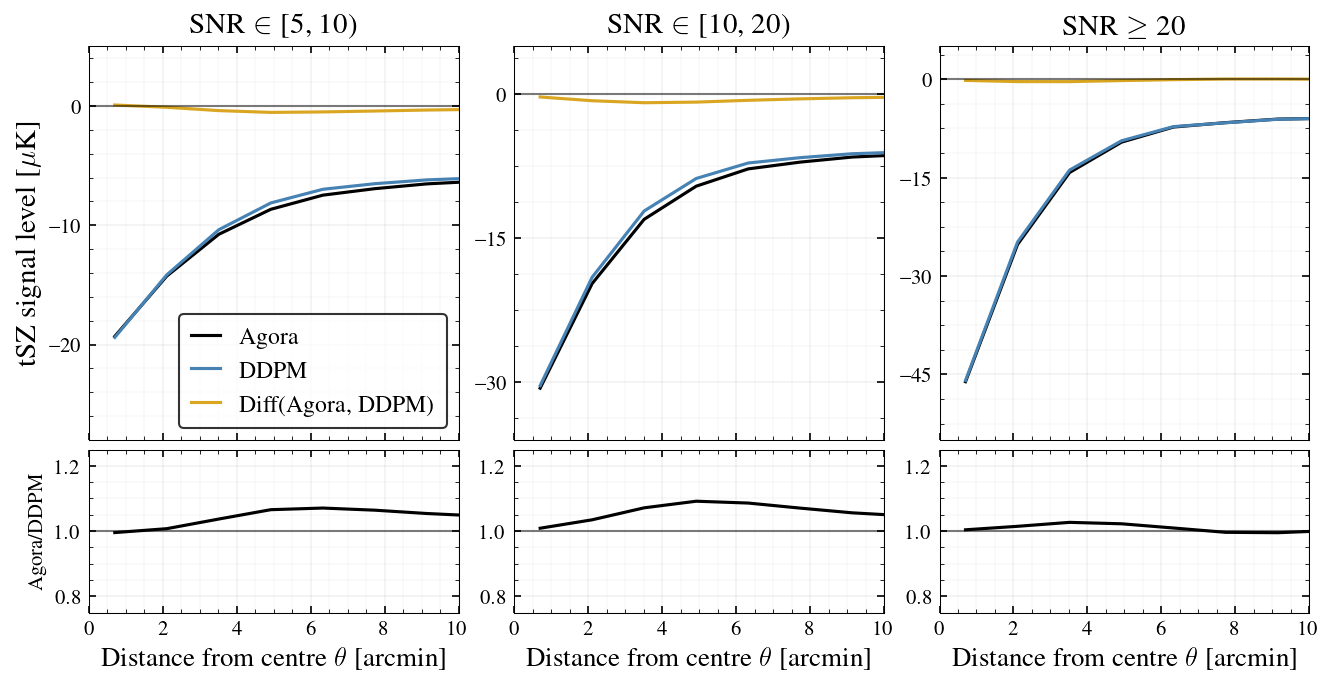

In [280]:
def radial_profile(z, xy = None, bin_size = 1., minbin = 0., maxbin = 15., to_arcmins = 0):

    """
    get the radial profile of an image (both real and fourier space)
    """

    z = np.asarray(z)
    if xy is None:
        x, y = np.indices(z.shape)
    else:
        x, y = xy

    radius = (x**2. + y**2.) ** 0.5
    if to_arcmins: radius *= 60.

    binarr=np.arange(minbin,maxbin,bin_size)
    radprf=np.zeros((len(binarr),3))

    hit_count=[]

    for b,bin in enumerate(binarr):
        ind=np.where((radius>=bin) & (radius<bin+bin_size))
        radprf[b,0]=(bin+bin_size/2.)
        hits = len(np.where(abs(z[ind])>0.)[0])

        if hits>0:
            radprf[b,1]=np.sum(z[ind])/hits
            radprf[b,2]=np.std(z[ind])
        hit_count.append(hits)

    hit_count=np.asarray(hit_count)
    std_mean=np.sum(radprf[:,2]*hit_count)/np.sum(hit_count)
    errval=std_mean/(hit_count)**0.5
    radprf[:,2]=errval

    return radprf

clf()
fsval = 12
figure(figsize = (10.5, 5.))
tr, tc = 10, len(mask_threshold_sigma_units_arr)
rspan = 7
subplots_adjust( wspace = 0.15, hspace = 0.2)
sbpl = 1
lwval = 1.5
ratio_plot_arr = []
maxxloc = 5
gridalphaval = 0.2
xmax = 10. #20.
for thresholdcntr, threshold in enumerate( mask_threshold_sigma_units_arr ):
    if threshold == (5.,10.):
        ymin, ymax = -28., 5.
        maxyloc = 4
    elif threshold == (10., 20.):
        ymin, ymax = -36., 5.
        maxyloc = 4
    elif threshold == (20., 100.):
        ymin, ymax = -55., 5.
        maxyloc = 4
        
    pl_arr = []
    for which_tsz in which_tsz_arr:
        curr_fname = 'tsz_extracts/%s_tsz_stacks.npy' %(which_tsz)
        cutout_dic = np.load(curr_fname, allow_pickle = True).item()    
        
        cutout_arr = cutout_dic[threshold]
        #print(cutout_arr); sys.exit()
        cutout_stack = np.mean( cutout_arr, axis = 0 )
        
        xarr = yarr = np.linspace( -cutout_size_pixels/2., cutout_size_pixels/2, cutout_size_pixels )
        xgrid, ygrid = np.meshgrid( xarr, yarr )

        radprf = radial_profile(cutout_stack, xy = (xgrid, ygrid))
        radprf_x, radprf_y, radprf_y_err = radprf.T
        #clf(); plot(radprf_x, radprf_y); show(); sys.exit()
    
        
        pl_arr.append( radprf_y )
        
    pl_arr = np.asarray( pl_arr )
    
    ratio_plot_arr.append( pl_arr[0]/pl_arr[1])
    xarr = radprf_x * dx_am
    print(xarr)
    #plot radial profile stack
    ax = subplot2grid( (tr, tc), (0, thresholdcntr), rowspan = rspan); 
    plot( xarr, pl_arr[0], color = 'black', lw = lwval, label = r'Agora')
    plot( xarr, pl_arr[1], color = 'steelblue', lw = lwval, label = r'DDPM')
    plot( xarr, pl_arr[0] - pl_arr[1], color = 'goldenrod', lw = lwval, label = r'Diff(Agora, DDPM)')
    if thresholdcntr == 0:
        legend(loc = 4, fontsize = fsval-0.5, handlelength = 1.2)
    axhline(0., lw = 1., alpha = 0.5)
    #xlabel(r'Distance from centre $\theta$', fontsize = fsval)
    if thresholdcntr == 0:
        ylabel(r'tSZ signal level [$\mu$K]', fontsize = fsval+2)
    ax.xaxis.set_major_locator(plt.MaxNLocator(maxxloc))
    ax.yaxis.set_major_locator(plt.MaxNLocator(maxyloc))
    #ylim(1., )
    xlim(0., xmax)
    ylim(ymin, ymax)
    grid(True, which = 'major', lw = 0.2, alpha = gridalphaval)
    grid(True, which = 'minor', lw = 0.1, alpha = gridalphaval)
    tit_val = r'SNR $\in$ [%g, %g)' %(threshold[0], threshold[1])
    if thresholdcntr==len(mask_threshold_sigma_units_arr)-1:
        tit_val = r'SNR $\ge$ %g' %(threshold[0])

    title(tit_val, fontsize = fsval+2)
    setp(ax.get_xticklabels(which = 'both'), visible=False)
    
#ratio
for thresholdcntr, threshold in enumerate( mask_threshold_sigma_units_arr ):
    curr_ratio = ratio_plot_arr[thresholdcntr]
    ax = subplot2grid( (tr, tc), (rspan, thresholdcntr), rowspan = tr-rspan); 
    plot( xarr, curr_ratio, color = 'black', lw = lwval, label = r'Agora')
    axhline(1., lw = 1., alpha = 0.5)
    if thresholdcntr == 0:
        ylabel(r'Agora/DDPM', fontsize = fsval-2)
    ax.xaxis.set_major_locator(plt.MaxNLocator(maxxloc))
    #ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ylim(0.75, 1.25)
    xlim(0., xmax)
    grid(True, which = 'major', lw = 0.2, alpha = gridalphaval)
    grid(True, which = 'minor', lw = 0.1, alpha = gridalphaval)
    xlabel(r'Distance from centre $\theta$ [arcmin]', fontsize = fsval+1)
show()
    

In [199]:
print(radprf_x) 
print(cutout_size_am)

[0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5]
22.5
